## Part 5

## ML Pipeline

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Generate data
X, y = make_classification(n_samples=200, n_features=5, random_state=0)

# Create pipeline
pipeline = Pipeline([
    ("scaling", StandardScaler()),
    ("model", LogisticRegression())
])

# Train pipeline
pipeline.fit(X, y)

# Make predictions
predictions = pipeline.predict(X)

## Missing Data

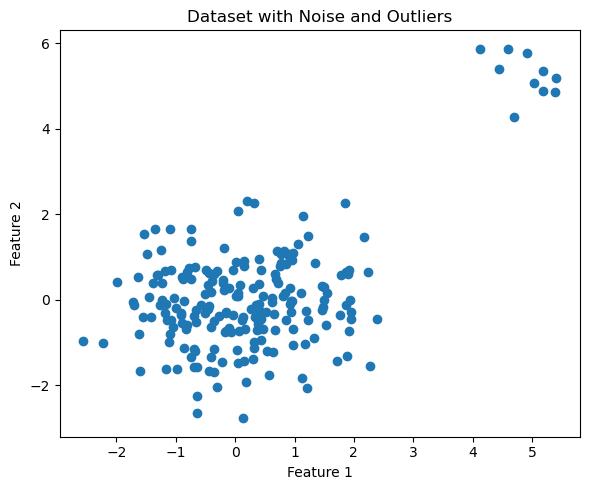

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate normal data
x1 = np.random.normal(0, 1, 200)
x2 = np.random.normal(0, 1, 200)

# Add outliers
x1_out = np.random.normal(5, 0.5, 10)
x2_out = np.random.normal(5, 0.5, 10)

x1 = np.concatenate([x1, x1_out])
x2 = np.concatenate([x2, x2_out])

plt.figure(figsize=(6,5))
plt.scatter(x1, x2)
plt.title("Dataset with Noise and Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

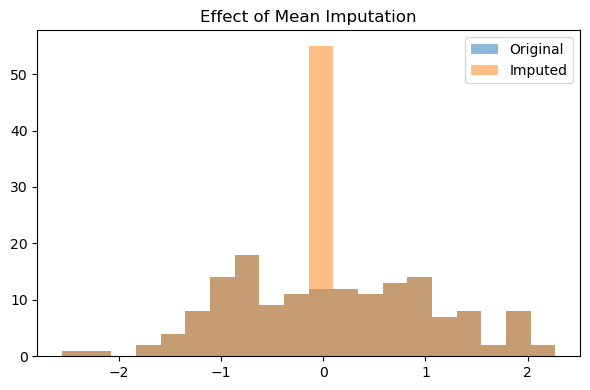

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

np.random.seed(0)

# Generate data
X = np.random.randn(200, 1)


# Introduce missing values
mask = np.random.rand(200) < 0.2
X[mask] = np.nan


# Impute using mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)


# Plot
plt.figure(figsize=(6,4))
plt.hist(X[~np.isnan(X)], bins=20, alpha=0.5, label="Original")
plt.hist(X_imputed, bins=20, alpha=0.5, label="Imputed")
plt.legend()
plt.title("Effect of Mean Imputation")
plt.tight_layout()
plt.savefig("/Figures/missing_data.pdf", dpi=300, bbox_inches="tight")

plt.show()

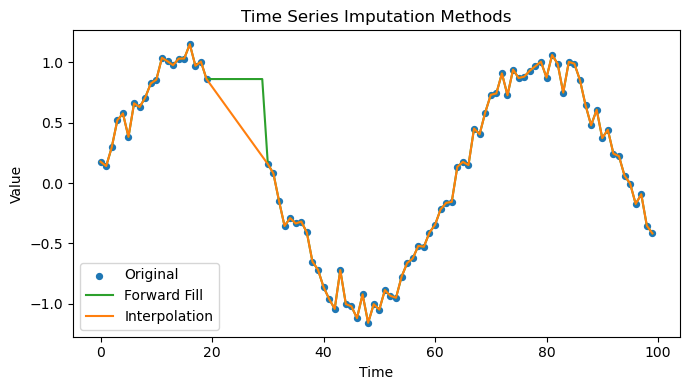

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# Create time series
time = np.arange(100)
values = np.sin(time / 10) + np.random.normal(0, 0.1, 100)

# Introduce missing values
values[20:30] = np.nan

df = pd.DataFrame({"time": time, "value": values})

# Imputation methods
ffill = df["value"].ffill()
interp = df["value"].interpolate()

# Plot
plt.figure(figsize=(7,4))
plt.scatter(df["time"], df["value"], label="Original", s=18, color='#1f77b4')
plt.plot(time, ffill, label="Forward Fill", color='#2ca02c')
plt.plot(time, interp, label="Interpolation", color='#ff7f0e')
plt.legend()
plt.title("Time Series Imputation Methods")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig("/Figures/time_series_missing.pdf", dpi=300, bbox_inches="tight")

plt.show()


## Outliers

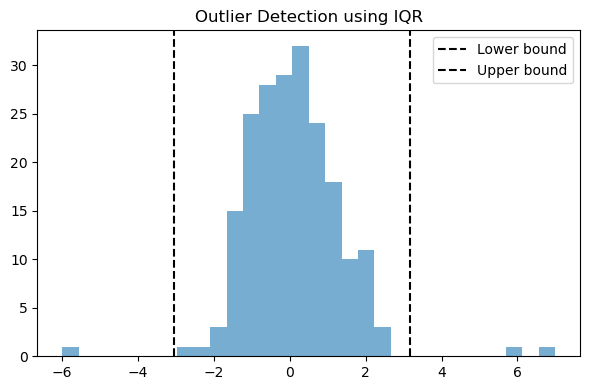

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate data
data = np.random.normal(0, 1, 200)

# Add outliers
data = np.concatenate([data, [6, 7, -6]])

# Compute IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers
outliers = data[(data < lower) | (data > upper)]

# Plot
plt.figure(figsize=(6,4))
plt.hist(data, bins=30, alpha=0.6)
plt.axvline(lower, linestyle='--', label="Lower bound", color='grey')
plt.axvline(upper, linestyle='--', label="Upper bound", color='black')
plt.legend()
plt.title("Outlier Detection using IQR")
plt.tight_layout()
plt.show()

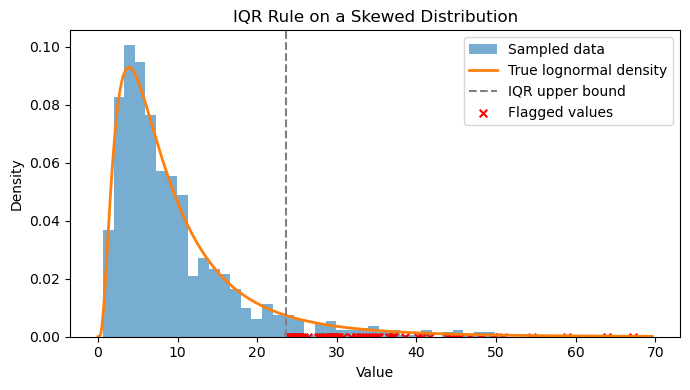

Upper IQR bound: 23.68
Number of flagged values: 70
Largest flagged values: [50.90509128 54.47600412 58.88224901 63.87827007 67.1872899 ]


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

np.random.seed(0)

# Generate a skewed distribution (e.g. purchase amounts)
mu = 2.0
sigma = 0.8
data = np.random.lognormal(mean=mu, sigma=sigma, size=1000)

# Compute IQR thresholds
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Flagged values
flagged = data[data > upper]

# Grid for true density
x = np.linspace(0.01, np.percentile(data, 99.5) * 1.4, 500)
pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

# Plot histogram and true density
plt.figure(figsize=(7,4))
plt.hist(data, bins=50, density=True, alpha=0.6, label="Sampled data")
plt.plot(x, pdf, linewidth=2, label="True lognormal density")
plt.axvline(upper, linestyle='--', label="IQR upper bound", color='grey')

# Mark flagged values along the x-axis
plt.scatter(flagged, np.zeros_like(flagged), marker='x', s=30, label="Flagged values", color='red')

plt.title("IQR Rule on a Skewed Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/outliers.pdf", dpi=300, bbox_inches="tight")

plt.show()

print(f"Upper IQR bound: {upper:.2f}")
print(f"Number of flagged values: {len(flagged)}")
print(f"Largest flagged values: {np.sort(flagged)[-5:]}")


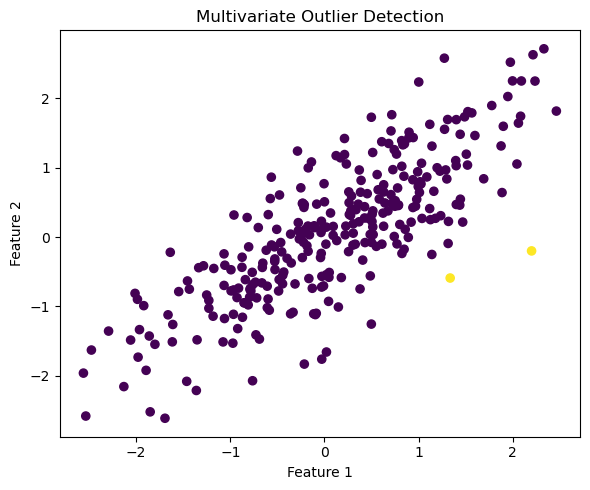

Flagged points: [294 300]


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(0)

# Generate correlated 2D data
mean = np.array([0, 0])
cov = np.array([[1.0, 0.8],
                [0.8, 1.0]])
X = np.random.multivariate_normal(mean, cov, size=300)

# Add unusual point that is not extreme in each coordinate individually
outlier = np.array([[2.2, -0.2]])
X_all = np.vstack([X, outlier])

# Estimate mean and covariance from main data
mu = X.mean(axis=0)
Sigma = np.cov(X.T)
Sigma_inv = np.linalg.inv(Sigma)

# Mahalanobis distances
diff = X_all - mu
md2 = np.sum(diff @ Sigma_inv * diff, axis=1)

# Threshold from chi-square distribution with 2 degrees of freedom
threshold = chi2.ppf(0.99, df=2)

# Flag outliers
flags = md2 > threshold

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_all[:, 0], X_all[:, 1], c=flags, s=35)
plt.title("Multivariate Outlier Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.savefig("/Figures/outliers_multi_dim.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Flagged points:", np.where(flags)[0])

## Class Imbalance

Accuracy: 0.990
Recall for minority class: 0.000


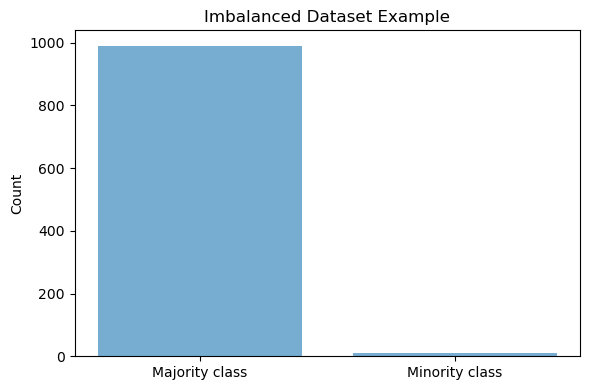

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score

# Create imbalanced labels
y_true = np.array([0] * 990 + [1] * 10)

# Dummy classifier predicts only majority class
y_pred = np.zeros_like(y_true)

acc = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"Recall for minority class: {recall:.3f}")

# Plot class distribution
classes = ["Majority class", "Minority class"]
counts = [np.sum(y_true == 0), np.sum(y_true == 1)]

plt.figure(figsize=(6,4))
plt.bar(classes, counts, alpha=0.6)
plt.title("Imbalanced Dataset Example")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/Figures/imbalanced_dataset.pdf", dpi=300, bbox_inches="tight")
plt.show()

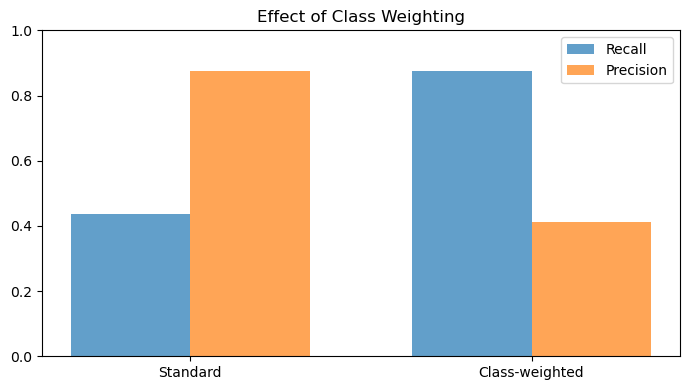

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import train_test_split

# Generate imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    weights=[0.95, 0.05],
    random_state=0
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Standard model
model_standard = LogisticRegression(max_iter=1000)
model_standard.fit(X_train, y_train)
pred_standard = model_standard.predict(X_test)

# Weighted model
model_weighted = LogisticRegression(max_iter=1000, class_weight="balanced")
model_weighted.fit(X_train, y_train)
pred_weighted = model_weighted.predict(X_test)

# Metrics
recall_standard = recall_score(y_test, pred_standard)
recall_weighted = recall_score(y_test, pred_weighted)

precision_standard = precision_score(y_test, pred_standard, zero_division=0)
precision_weighted = precision_score(y_test, pred_weighted, zero_division=0)

# Plot recall and precision comparison
labels = ["Standard", "Class-weighted"]
recalls = [recall_standard, recall_weighted]
precisions = [precision_standard, precision_weighted]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, recalls, width, label="Recall", alpha=0.7)
plt.bar(x + width/2, precisions, width, label="Precision", alpha=0.7)
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Effect of Class Weighting")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/imbalanced_handling.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pip install imblearn

Baseline model on original training data
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       329
           1       1.00      0.87      0.93        31

    accuracy                           0.99       360
   macro avg       0.99      0.94      0.96       360
weighted avg       0.99      0.99      0.99       360

Model trained after SMOTE
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       329
           1       0.47      0.90      0.62        31

    accuracy                           0.90       360
   macro avg       0.73      0.90      0.78       360
weighted avg       0.94      0.90      0.92       360



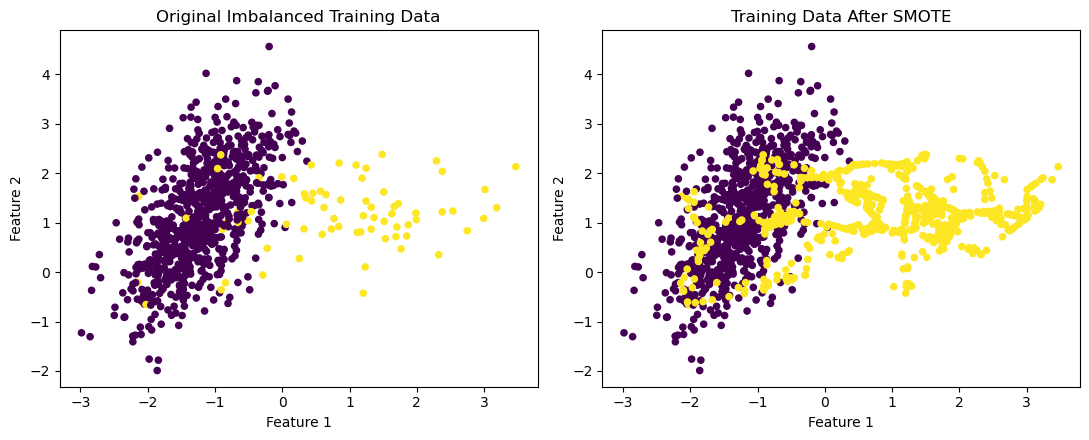

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Create an imbalanced binary classification dataset
X, y = make_classification(
    n_samples=1200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    weights=[0.92, 0.08],
    class_sep=1.2,
    random_state=0
)

# Split before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)

# Train a baseline model on the original imbalanced data
baseline_model = LogisticRegression(random_state=0)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("Baseline model on original training data")
print(classification_report(y_test, y_pred_baseline))

# Apply SMOTE only to the training data
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train a model on the SMOTE-resampled data
smote_model = LogisticRegression(random_state=0)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

print("Model trained after SMOTE")
print(classification_report(y_test, y_pred_smote))

# Plot original and SMOTE-resampled training data
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20)
axes[0].set_title("Original Imbalanced Training Data")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_train_smote[:, 0], X_train_smote[:, 1], c=y_train_smote, s=20)
axes[1].set_title("Training Data After SMOTE")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.savefig("/Figures/smote.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Model Deployment and Monitoring

Training MSE: 1.01
Later-period MSE: 34.30


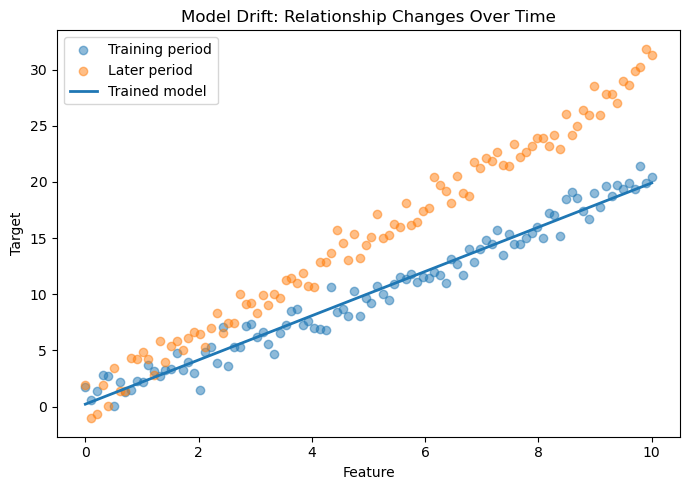

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(0)

# Training period
X_train = np.linspace(0, 10, 100).reshape(-1, 1)
y_train = 2 * X_train.squeeze() + np.random.normal(0, 1, 100)

# Later period with changed relationship
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_test = 3 * X_test.squeeze() + np.random.normal(0, 1, 100)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print(f"Training MSE: {train_mse:.2f}")
print(f"Later-period MSE: {test_mse:.2f}")

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, alpha=0.5, label="Training period")
plt.scatter(X_test, y_test, alpha=0.5, label="Later period")
plt.plot(X_train, y_pred_train, linewidth=2, label="Trained model")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Model Drift: Relationship Changes Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/model_drift.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
## Data Drift

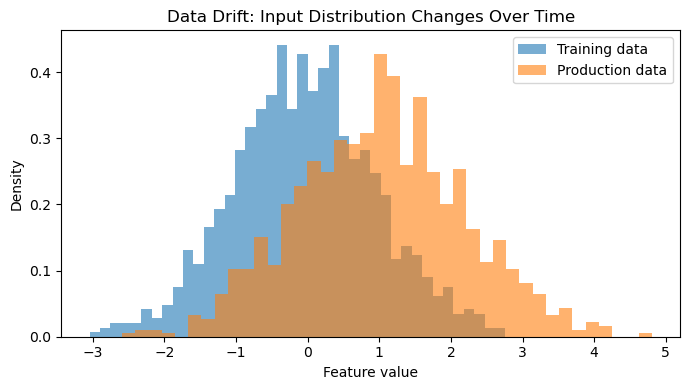

In [55]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Training feature distribution
train_data = np.random.normal(loc=0, scale=1, size=1000)

# Production feature distribution after drift
prod_data = np.random.normal(loc=1.0, scale=1.2, size=1000)

plt.figure(figsize=(7,4))
plt.hist(train_data, bins=40, alpha=0.6, density=True, label="Training data")
plt.hist(prod_data, bins=40, alpha=0.6, density=True, label="Production data")
plt.xlabel("Feature value")
plt.ylabel("Density")
plt.title("Data Drift: Input Distribution Changes Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/data_drift.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Production ML systems

In [50]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Train a simple model
X, y = make_classification(n_samples=200, n_features=5, random_state=0)
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Simulated serving function
def serve_prediction(input_features):
    input_array = np.array(input_features).reshape(1, -1)
    probability = model.predict_proba(input_array)[0, 1]
    prediction = model.predict(input_array)[0]
    return {"prediction": int(prediction), "probability": float(probability)}

# Example request
result = serve_prediction([0.1, -1.2, 0.4, 0.7, -0.3])
print(result)

{'prediction': 0, 'probability': 0.07096855821141193}


In [51]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Train model
X, y = make_classification(n_samples=200, n_features=5, random_state=0)
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Batch inference: many examples at once
batch_inputs = X[:5]
batch_predictions = model.predict(batch_inputs)
print("Batch predictions:", batch_predictions)

# Real-time inference: one request at a time
single_input = X[5].reshape(1, -1)
single_prediction = model.predict(single_input)
print("Real-time prediction:", single_prediction[0])

Batch predictions: [1 1 0 1 0]
Real-time prediction: 0


## Online Learning

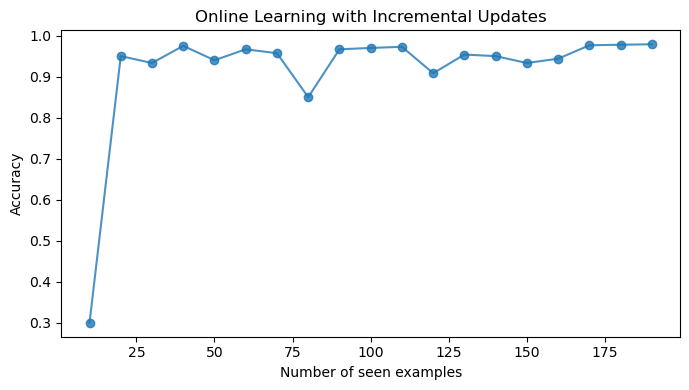

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier

np.random.seed(0)

# Simulated streaming binary classification data
X = np.random.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Incremental learner
model = SGDClassifier(loss="log_loss", random_state=0)

accuracies = []

# Online updates in small chunks
for i in range(10, 200, 10):
    X_batch = X[i-10:i]
    y_batch = y[i-10:i]

    if i == 10:
        model.partial_fit(X_batch, y_batch, classes=np.array([0, 1]))
    else:
        model.partial_fit(X_batch, y_batch)

    y_pred = model.predict(X[:i])
    acc = np.mean(y_pred == y[:i])
    accuracies.append(acc)

plt.figure(figsize=(7,4))
plt.plot(range(10, 200, 10), accuracies, marker='o', alpha=0.8)
plt.xlabel("Number of seen examples")
plt.ylabel("Accuracy")
plt.title("Online Learning with Incremental Updates")
plt.tight_layout()
plt.savefig("/Figures/online_learning.pdf", dpi=300, bbox_inches="tight")
plt.show()

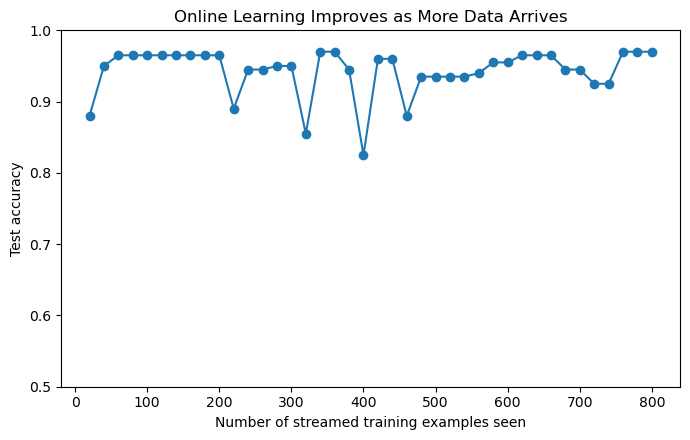

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Create a streamable binary classification problem
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.01,
    random_state=100
)

# Use the first part as a fixed test set to monitor progress
X_test, y_test = X[:200], y[:200]
X_stream, y_stream = X[200:], y[200:]

# Incremental classifier
model = SGDClassifier(loss="log_loss", random_state=0)

batch_size = 20
seen_examples = []
accuracies = []

# Feed the training data as a stream in small batches
for i in range(batch_size, len(X_stream) + 1, batch_size):
    X_batch = X_stream[i - batch_size:i]
    y_batch = y_stream[i - batch_size:i]

    if i == batch_size:
        model.partial_fit(X_batch, y_batch, classes=np.array([0, 1]))
    else:
        model.partial_fit(X_batch, y_batch)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    seen_examples.append(i)
    accuracies.append(acc)

# Plot test accuracy as more streamed examples are observed
plt.figure(figsize=(7, 4.5))
plt.plot(seen_examples, accuracies, marker="o")
plt.xlabel("Number of streamed training examples seen")
plt.ylabel("Test accuracy")
plt.title("Online Learning Improves as More Data Arrives")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


## Scaling ML

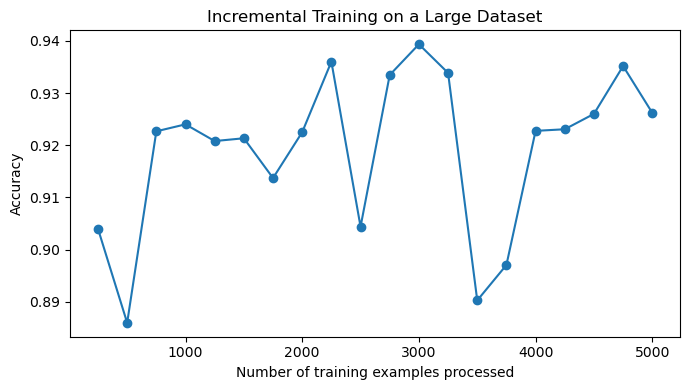

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import SGDClassifier

# Generate a larger synthetic dataset
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    random_state=0
)

# Incremental training in mini-batches
model = SGDClassifier(loss="log_loss", random_state=0)

batch_size = 250
accuracies = []

for start in range(0, len(X), batch_size):
    end = start + batch_size
    X_batch = X[start:end]
    y_batch = y[start:end]

    if start == 0:
        model.partial_fit(X_batch, y_batch, classes=np.array([0, 1]))
    else:
        model.partial_fit(X_batch, y_batch)

    y_pred = model.predict(X[:end])
    acc = np.mean(y_pred == y[:end])
    accuracies.append(acc)

plt.figure(figsize=(7,4))
plt.plot(range(batch_size, len(X) + 1, batch_size), accuracies, marker='o')
plt.xlabel("Number of training examples processed")
plt.ylabel("Accuracy")
plt.title("Incremental Training on a Large Dataset")
plt.tight_layout()
plt.savefig("/Figures/scaling_ML_minibatch.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Distributed Training

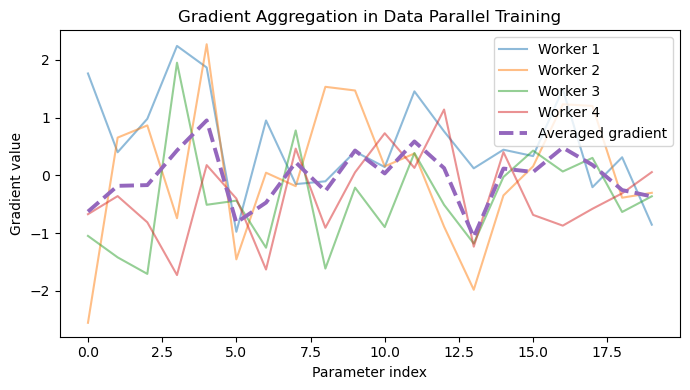

In [64]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Simulated gradients from 4 workers
worker_grads = [
    np.random.normal(0, 1, 20),
    np.random.normal(0, 1, 20),
    np.random.normal(0, 1, 20),
    np.random.normal(0, 1, 20)
]

# Aggregate by averaging, as in synchronous data parallel training
avg_grad = np.mean(worker_grads, axis=0)

# Plot
plt.figure(figsize=(7,4))
for i, g in enumerate(worker_grads):
    plt.plot(g, alpha=0.5, label=f"Worker {i+1}")
plt.plot(avg_grad, linestyle='--', linewidth=2.8, label="Averaged gradient")
plt.xlabel("Parameter index")
plt.ylabel("Gradient value")
plt.title("Gradient Aggregation in Data Parallel Training")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/distributed_gradient_aggregation.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experimentation
### A/B testing

Control conversion rate: 0.108
Treatment conversion rate: 0.142
Observed lift: 0.034


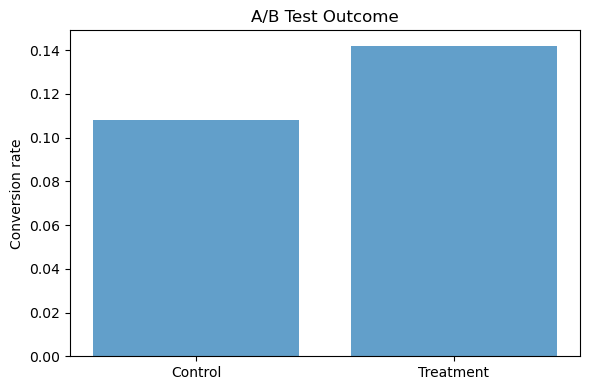

In [67]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Simulate binary outcomes such as conversion
n = 1000
control = np.random.binomial(1, 0.10, size=n)
treatment = np.random.binomial(1, 0.12, size=n)

control_rate = control.mean()
treatment_rate = treatment.mean()
lift = treatment_rate - control_rate

print(f"Control conversion rate: {control_rate:.3f}")
print(f"Treatment conversion rate: {treatment_rate:.3f}")
print(f"Observed lift: {lift:.3f}")

# Plot
labels = ["Control", "Treatment"]
values = [control_rate, treatment_rate]

plt.figure(figsize=(6,4))
plt.bar(labels, values, alpha=0.7)
plt.ylabel("Conversion rate")
plt.title("A/B Test Outcome")
plt.tight_layout()
plt.savefig("/Figures/AB_testing.pdf", dpi=300, bbox_inches="tight")

plt.show()

### Adaptive multi-band bandits

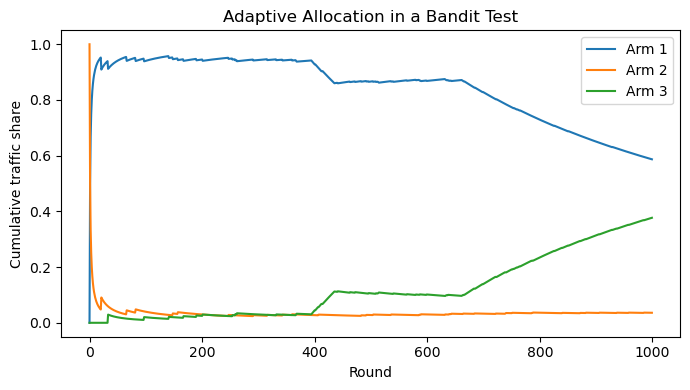

Assignments: [587  36 377]
Estimated rates: [0.082 0.028 0.159]


In [69]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# True click probabilities of 3 alternatives
true_rates = [0.08, 0.10, 0.14]
n_rounds = 1000
epsilon = 0.1

counts = np.zeros(3)
successes = np.zeros(3)
choices = []

for t in range(n_rounds):
    # Explore with probability epsilon
    if np.random.rand() < epsilon or np.sum(counts) == 0:
        arm = np.random.randint(3)
    else:
        estimates = np.divide(
            successes,
            counts,
            out=np.zeros_like(successes),
            where=counts > 0
        )
        arm = np.argmax(estimates)

    # Simulate binary reward
    reward = np.random.rand() < true_rates[arm]

    counts[arm] += 1
    successes[arm] += reward
    choices.append(arm)

# Cumulative share of traffic assigned to each arm
choices = np.array(choices)
shares = np.array([
    np.cumsum(choices == i) / np.arange(1, n_rounds + 1)
    for i in range(3)
])

plt.figure(figsize=(7,4))
for i in range(3):
    plt.plot(shares[i], label=f"Arm {i+1}")
plt.xlabel("Round")
plt.ylabel("Cumulative traffic share")
plt.title("Adaptive Allocation in a Bandit Test")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/bandit_allocation.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Assignments:", counts.astype(int))
print("Estimated rates:", np.round(successes / counts, 3))